In [1]:
# Basic tools
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn tools
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the Iris dataset directly from sklearn
iris = load_iris()

# Convert to a pandas DataFrame for easier handling
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Show first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
# Basic info
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDescriptive statistics:")
print(df.describe())
print("\nSpecies distribution:")
print(df['species_name'].value_counts())

Shape: (150, 6)

Data types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
species_name          object
dtype: object

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Descriptive statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

    

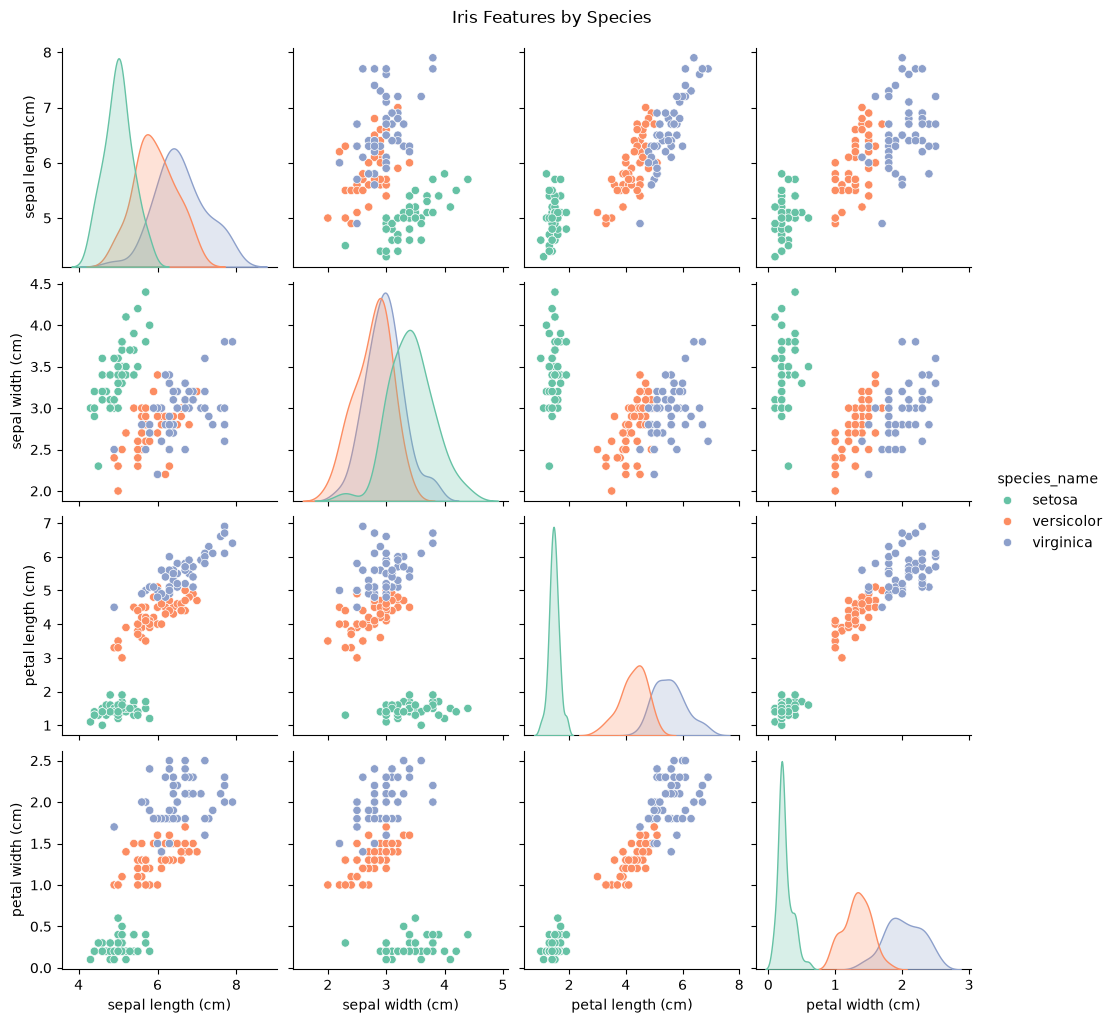

In [4]:
# Pairplot: shows relationships between all features, colored by species
sns.pairplot(df, hue='species_name', vars=iris.feature_names, palette='Set2')
plt.suptitle('Iris Features by Species', y=1.02)
plt.savefig('../models/pairplot.png', dpi=100, bbox_inches='tight')
plt.show()

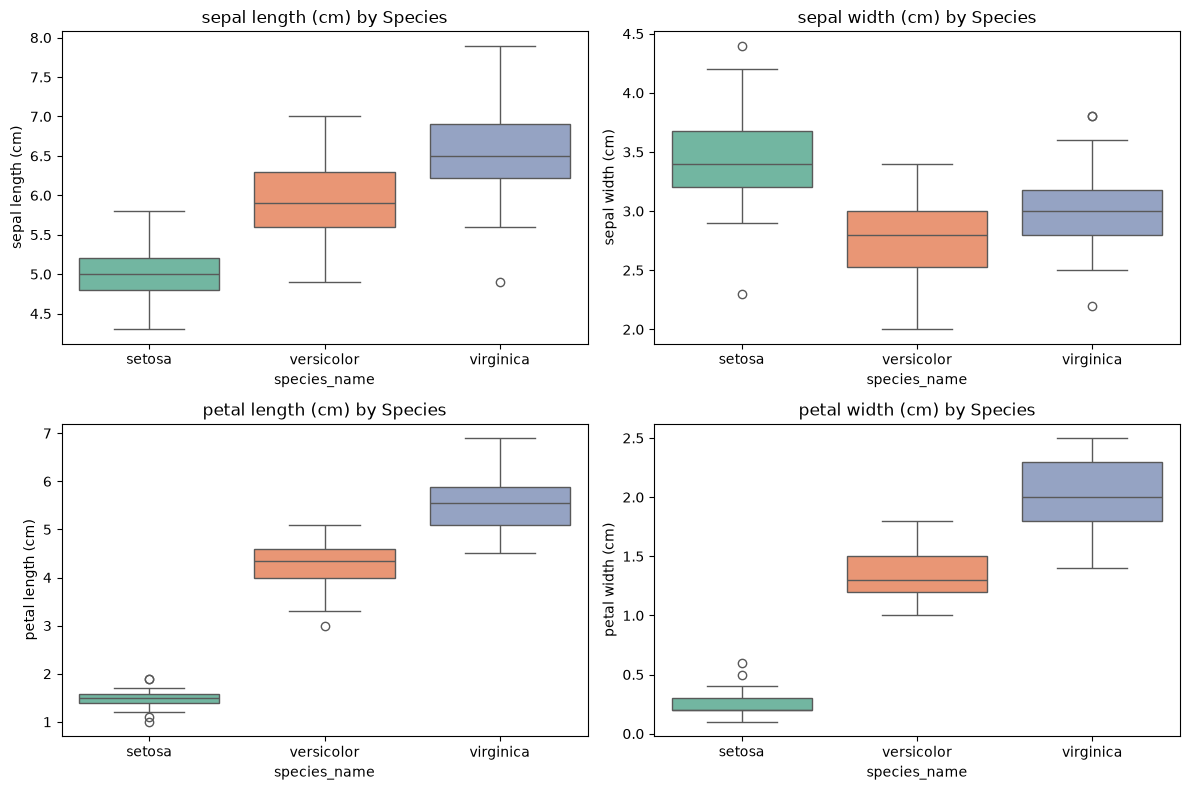

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = iris.feature_names
for i, feature in enumerate(features):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x='species_name', y=feature, hue='species_name', legend=False, palette='Set2', ax=axes[row, col])
    axes[row, col].set_title(f'{feature} by Species')

plt.tight_layout()
plt.savefig('../models/boxplots.png', dpi=100, bbox_inches='tight')
plt.show()

Feature selection discussion

Looking at the pairplot and box plots above, petal length and petal width show the clearest separation between species. Setosa especially stands out with small petal measurements that barely overlap with the other two species. Sepal length and sepal width show more overlap between Versicolor and Virginica, so they are less reliable on their own.

Based on this, petal measurements seem to be the strongest features for classification, but we will still use all four features together since they add useful information.

In [6]:
X = df[iris.feature_names]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (120, 4)
Testing data size: (30, 4)


In [7]:
# Define pipelines: each combines scaling + a classifier
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42))
    ]),
    'K-Nearest Neighbors': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', KNeighborsClassifier())
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', RandomForestClassifier(random_state=42))
    ])
}

print("Pipelines created for:", list(pipelines.keys()))

Pipelines created for: ['Logistic Regression', 'K-Nearest Neighbors', 'Random Forest']


In [8]:
print("Cross-validation results (5-fold):\n")

cv_results = {}
for name, pipeline in pipelines.items():
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Scores across 5 folds: {scores.round(3)}")
    print(f"  Mean accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})\n")

Cross-validation results (5-fold):

Logistic Regression:
  Scores across 5 folds: [0.917 0.958 0.958 0.958 1.   ]
  Mean accuracy: 0.958 (+/- 0.026)

K-Nearest Neighbors:
  Scores across 5 folds: [0.917 1.    0.958 0.958 1.   ]
  Mean accuracy: 0.967 (+/- 0.031)

Random Forest:
  Scores across 5 folds: [0.917 0.958 0.958 0.958 0.958]
  Mean accuracy: 0.950 (+/- 0.017)



In [9]:
# Tune KNN: try different numbers of neighbors
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance']
}

grid_search = GridSearchCV(
    pipelines['K-Nearest Neighbors'],
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'classifier__n_neighbors': 5, 'classifier__weights': 'uniform'}
Best cross-validation accuracy: 0.9666666666666668


In [10]:
# Use the best model found by GridSearchCV
best_model = grid_search.best_estimator_

# Predict on test data
y_pred = best_model.predict(X_test)

# Evaluate
print("Test set accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Test set accuracy: 0.9333333333333333

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



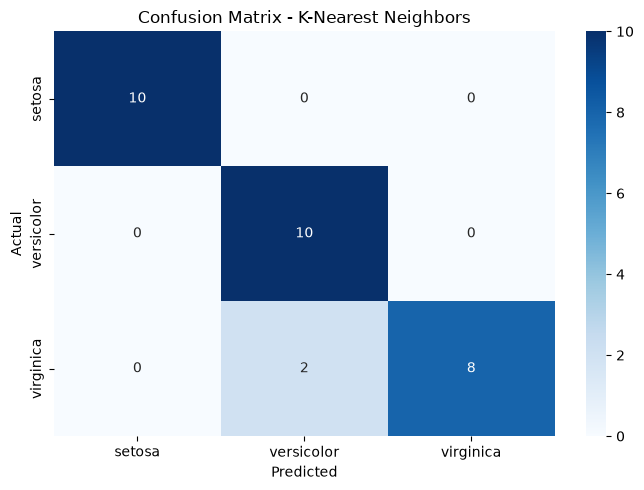

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix - K-Nearest Neighbors')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../models/confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

In [12]:
print("Final comparison of all models on test set:\n")

results_summary = []
for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results_summary.append({'Model': name, 'Test Accuracy': acc})
    print(f"{name}: {acc:.3f}")

results_df = pd.DataFrame(results_summary).sort_values('Test Accuracy', ascending=False)
print("\nBest model:", results_df.iloc[0]['Model'])

Final comparison of all models on test set:

Logistic Regression: 0.933
K-Nearest Neighbors: 0.933
Random Forest: 0.900

Best model: Logistic Regression


In [13]:
import joblib

# Save the best model (tuned KNN)
joblib.dump(best_model, '../models/iris_classifier.pkl')

print("Model saved successfully!")

Model saved successfully!


Conclusion

This project builds a classifier to identify iris flower species (setosa, versicolor, virginica) based on sepal and petal measurements, using the classic Iris dataset from scikit-learn.

Three models were compared using 5-fold cross-validation: Logistic Regression, K-Nearest Neighbors, and Random Forest. KNN had the best cross-validation accuracy (96.7%), and after tuning with GridSearchCV, the default settings (5 neighbors, uniform weighting) turned out to already be optimal.

On the final test set, Logistic Regression and KNN tied at 93.3% accuracy, with Random Forest slightly behind at 90%. KNN was selected as the final model based on its stronger and more consistent cross-validation performance.

Petal length and petal width were found to be the most useful features for distinguishing species, especially for identifying setosa, which was classified with 100% accuracy in every test. Most misclassifications occurred between versicolor and virginica, which have more overlapping measurements.

Tools used: Python, pandas, scikit-learn,